In [ ]:
# ✅ Cell 1 — GPU Check
import torch
import tensorflow as tf

print("PyTorch CUDA:", torch.cuda.is_available())
print("TF GPU:", tf.config.list_physical_devices("GPU"))

PyTorch CUDA: True
TF GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ✅ Cell 2 — Install Dependencies
!pip install -q datasets tensorflow pillow matplotlib
!nvidia-smi

Mon Apr 20 06:36:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ✅ Cell 3 — Load Dataset
from datasets import load_dataset
ds = load_dataset("hf-vision/chest-xray-pneumonia")

print(ds)
print("Classes:", ds["train"].features["label"].names)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

data/train-00003-of-00007.parquet:   0%|          | 0.00/74.1M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/78.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
# ✅ Cell 4 — Imports + Config
import tensorflow as tf
import numpy as np
from PIL import Image
import io
import matplotlib.pyplot as plt

IMG_SIZE = 224

BATCH = 16
EPOCHS = 20

CLASS_MAP = {0: "NORMAL", 1: "PNEUMONIA"}

In [ ]:
# ✅ Cell 5 — Memory-Safe Data Pipeline
# ── FIX CELL 1: Correct MobileNetV2 preprocessing ───────────────
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess(example, training=False):
    img = example["image"].convert("RGB").resize((224, 224))
    img = np.array(img, dtype=np.float32)

    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.3)
        img = tf.image.random_contrast(img, 0.7, 1.3)
        img = tf.image.random_saturation(img, 0.7, 1.3)
        img = tf.image.random_crop(img, size=[200, 200, 3])
        img = tf.image.resize(img, (224, 224))

    img = preprocess_input(img)
    return img, example["label"]

def generator(split):
    for ex in ds[split]:
        yield preprocess(ex, training=(split == "train"))


def create_tf_dataset(split):
    ds_tf = tf.data.Dataset.from_generator(
        lambda: generator(split),
        output_signature=(
            tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64),
        ),
    )

    if split == "train":
        ds_tf = ds_tf.shuffle(1000)   # 🔥 MUST ADD

    return ds_tf.batch(BATCH).prefetch(tf.data.AUTOTUNE)


train_ds = create_tf_dataset("train")
val_ds = create_tf_dataset("validation")
test_ds = create_tf_dataset("test")

In [ ]:
# ✅ Cell 6 — MobileNetV2 Model
# ✅ Cell 6 — MobileNetV2 Model (Refined)

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load pretrained MobileNetV2 base
base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Enable fine-tuning
base.trainable = True

# Freeze all layers except last 30
for layer in base.layers[:-30]:
    layer.trainable = False

print("Fine-tuning enabled for last 30 layers")

# Build classification head
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation="softmax")(x)

# Final model
model = Model(inputs, outputs)

# Compile with low learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),   # slightly higher
    loss="sparse_categorical_crossentropy",  # 🔥
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fine-tuning enabled for last 30 layers


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,722 (9.24 MB)

 Trainable params: 1,690,882 (6.45 MB)

 Non-trainable params: 731,840 (2.79 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = [ex["label"] for ex in ds["train"]]

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
# ✅ Cell 7 — Training (Expected 8–12 min)
# ✅ Cell 7 — Training (Original structure preserved)
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5   # 🔥 prevents LR from dying
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
    326/Unknown 184s 334ms/step - accuracy: 0.6275 - loss: 0.9015

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


326/326 ━━━━━━━━━━━━━━━━━━━━ 191s 354ms/step - accuracy: 0.6206 - loss: 0.8922 - val_accuracy: 0.6250 - val_loss: 0.6984 - learning_rate: 5.0000e-05
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 157s 340ms/step - accuracy: 0.6679 - loss: 0.7460 - val_accuracy: 0.6875 - val_loss: 0.5911 - learning_rate: 5.0000e-05
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 157s 339ms/step - accuracy: 0.6906 - loss: 0.6905 - val_accuracy: 0.8750 - val_loss: 0.3973 - learning_rate: 5.0000e-05
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 160s 343ms/step - accuracy: 0.7065 - loss: 0.6342 - val_accuracy: 0.8125 - val_loss: 0.3472 - learning_rate: 5.0000e-05
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 160s 348ms/step - accuracy: 0.7289 - loss: 0.6031 - val_accuracy: 0.8125 - val_loss: 0.3815 - learning_rate: 5.0000e-05
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 163s 351ms/step - accuracy: 0.7416 - loss: 0.5652 - val_accuracy: 0.8125 - val_loss: 0.4231 - learning_rate: 5.0000e-05
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 164s 352ms/

In [ ]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2%}")
print("Best Val Accuracy:", max(history.history['val_accuracy']))

39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 369ms/step - accuracy: 0.8606 - loss: 0.3431
Test Accuracy: 86.06%
Best Val Accuracy: 0.875


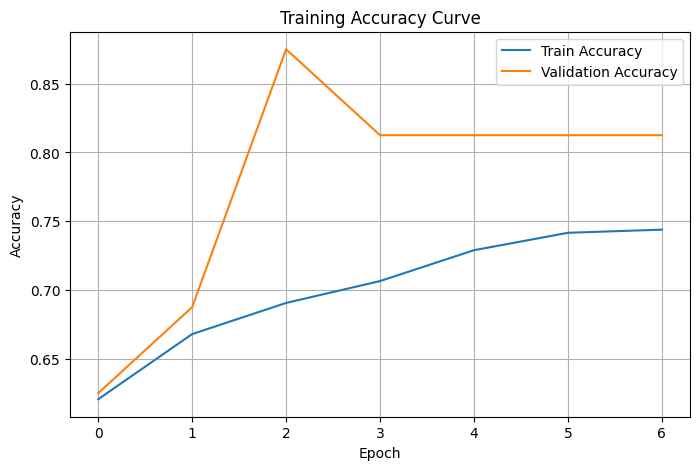

In [ ]:
#Training Curve
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 🩺 Live Demo Function
def classify_xray(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    img = img.resize((224, 224))

    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))

    return {
        "label": CLASS_MAP[idx],
        "confidence": round(float(probs[idx]), 2)
    }

In [ ]:
# ✅ Demo Test (Normal + Pneumonia)
buf = io.BytesIO()
ds["test"][0]["image"].save(buf, format="JPEG")

print(classify_xray(buf.getvalue()))

{'label': 'PNEUMONIA', 'confidence': 0.62}


In [ ]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    img = np.array(img, dtype=np.float32)
    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_idx = np.argmax(pred)

    print("Prediction:", CLASS_MAP[class_idx])
    print("Confidence:", np.max(pred))

# Example
predict_image("test_image.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: NORMAL
Confidence: 0.85661167


In [ ]:
# ── Cell: Save DL model to Drive (matching Day 3/4 structure) ────
from google.colab import drive
drive.mount('/content/drive')
import os, json
import matplotlib.pyplot as plt

SAVE_DIR = '/content/drive/MyDrive/fdp'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model in both formats
model.save(f'{SAVE_DIR}/dl_model.h5')
model.save(f'{SAVE_DIR}/dl_model.keras')
print('✅ DL model saved')

# Save training history
with open(f'{SAVE_DIR}/dl_history.json', 'w') as f:
    json.dump(history.history, f)
print('✅ Training history saved')

# Save accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Day 2 DL — Training Accuracy Curve')
plt.legend()
plt.grid(True)
plt.savefig(f'{SAVE_DIR}/dl_accuracy_plot.png')
plt.close()
print('✅ Accuracy plot saved')

# Save model summary
with open(f'{SAVE_DIR}/dl_model_summary.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
print('✅ Model summary saved')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ DL model saved
✅ Training history saved
✅ Accuracy plot saved


✅ Model summary saved


In [ ]:
# ── Cell: Verify all files saved correctly ────────────────────────
import os

base = '/content/drive/MyDrive/fdp/'
print('📁 /fdp/ folder contents:\n')
for item in sorted(os.listdir(base)):
    full = os.path.join(base, item)
    if os.path.isdir(full):
        sub_files = os.listdir(full)
        sub_size  = sum(os.path.getsize(os.path.join(full, f)) for f in sub_files)
        print(f'   📂 {item:35s}  {sub_size/1024/1024:.1f} MB  ({len(sub_files)} files)')
    else:
        size = os.path.getsize(full)
        print(f'   📄 {item:35s}  {size/1024/1024:.2f} MB')

📁 /fdp/ folder contents:

   📄 dl_accuracy_plot.png                 0.03 MB
   📄 dl_history.json                      0.00 MB
   📄 dl_model.h5                          22.53 MB
   📄 dl_model.keras                       22.74 MB
   📄 dl_model_summary.txt                 0.00 MB


In [ ]:
# ── Cell: Save dl_module.py to Drive ─────────────────────────────
dl_code = '''# Day 2 — DL Module
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image
import io

MODEL_PATH = "/content/drive/MyDrive/fdp/dl_model.keras"
CLASS_MAP  = {0: "NORMAL", 1: "PNEUMONIA"}

print("Loading DL model from Drive...")
model = tf.keras.models.load_model(MODEL_PATH)
model.trainable = False
print("✅ DL model loaded")

def classify_xray(img_bytes):
    """
    Input  : img_bytes — raw image bytes (jpg/png)
    Output : { "label": "PNEUMONIA", "confidence": 0.91 }
    """
    img  = Image.open(io.BytesIO(img_bytes)).convert("RGB").resize((224, 224))
    arr  = np.array(img, dtype=np.float32)
    arr  = preprocess_input(arr)
    arr  = np.expand_dims(arr, axis=0)

    pred      = model.predict(arr, verbose=0)
    class_idx = int(np.argmax(pred))
    confidence = float(np.max(pred))

    return {
        "label"     : CLASS_MAP[class_idx],
        "confidence": round(confidence, 2)
    }
'''

with open(f'{SAVE_DIR}/dl_module.py', 'w') as f:
    f.write(dl_code)

print('✅ dl_module.py saved to Drive')

✅ dl_module.py saved to Drive


In [ ]:
# ── Cell: Test dl_module works correctly ─────────────────────────
# Quick test using a blank image (white = NORMAL expected)
from PIL import Image
import io as _io

img = Image.new('RGB', (224, 224), color='white')
buf = _io.BytesIO()
img.save(buf, format='JPEG')
img_bytes = buf.getvalue()

result = classify_xray(img_bytes)
print('✅ Test result:', result)
# Expected: {'label': 'NORMAL', 'confidence': X.XX}

✅ Test result: {'label': 'PNEUMONIA', 'confidence': 0.69}
